In [2]:
import pandas as pd
from datetime import datetime

In [3]:
import morethemes as mt
import matplotlib.pyplot as plt

mt.set_theme("urban")

# https://coolors.co/1a4848-f7b000-f46036-c9f2c7-aceca1
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=["#1a4848", "#f7b000", "#f46036", "#c9f2c7", "#aceca1"]
)

# remove top and right spines for all plots in matplotlib params
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

from pyfonts import load_google_font

bold_font = load_google_font("Urbanist", weight="bold")

## Discourse page views

In [4]:
import json
import os
import requests
import dotenv

url = "https://festim.discourse.group/admin/reports/consolidated_page_views.json"
dotenv.load_dotenv()
API_KEY = os.getenv("DISCOURSE_API_KEY")
assert API_KEY is not None, "DISCOURSE_API_KEY environment variable is not set"
end_date = datetime.now()
start_date = datetime(2022, 1, 1)

url += f"?start_date={start_date}&end_date={end_date}"

payload = {}
headers = {"Accept": "application/json", "Api-Key": API_KEY, "Api-Username": "remidm"}

response = requests.request("GET", url, headers=headers, data=payload)
response_data = json.loads(response.text)

In [5]:
# print(response_data)
data = pd.DataFrame(response_data["report"]["data"])

data.head()

,req,label,color,data
0,page_view_logged_in,Logged in users,#1EB8D1,"[{'x': '2023-11-23', 'y': 41}, {'x': '2023-11-..."
1,page_view_anon,Anonymous users,#9BC53D,"[{'x': '2023-11-23', 'y': 9}, {'x': '2023-11-2..."
2,page_view_crawler,Crawlers,#721D8D,"[{'x': '2023-11-24', 'y': 2}, {'x': '2023-11-2..."


In [6]:
data_filtered = {}

for row in data.itertuples():
    xs = [point['x'] for point in row.data]
    ys = [point['y'] for point in row.data]
    # convert to datetime
    xs = [datetime.strptime(x, "%Y-%m-%d") for x in xs]
    data_filtered[row.label] = (xs, ys)


In [7]:
# make a new dataframe with Day as the index and "logged in", "anonymous", "crawlers" as columns

all_days = set()
for label, (xs, ys) in data_filtered.items():
    all_days.update(xs)

all_days = sorted(all_days)

df = pd.DataFrame(columns=data_filtered.keys(), index=all_days)

for label, (xs, ys) in data_filtered.items():
    for x, y in zip(xs, ys):
        df.loc[x, label] = y

# set index name
df.index.name = "Day"

# convert index to column
df.reset_index(inplace=True)
df

,Day,Logged in users,Anonymous users,Crawlers
0,2023-11-23,41,9,NaN
1,2023-11-24,15,5,2
2,2023-11-26,1,18,NaN
3,2023-11-27,75,25,1
4,2023-11-28,92,41,1
...,...,...,...,...
888,2026-05-04,2,139,149
889,2026-05-05,1,145,132
890,2026-05-06,3,157,200
891,2026-05-07,16,164,197


In [8]:
# group per month based on the "Day" index (sum numeric columns only)
discourse_page_views_monthly = df.groupby(
    df["Day"].dt.to_period("M")
)[["Logged in users", "Anonymous users", "Crawlers"]].sum()

discourse_page_views_monthly.head()

,Logged in users,Anonymous users,Crawlers
Day,,,
2023-11,276,113,4
2023-12,474,124,41
2024-01,251,70,96
2024-02,242,92,58
2024-03,153,49,77


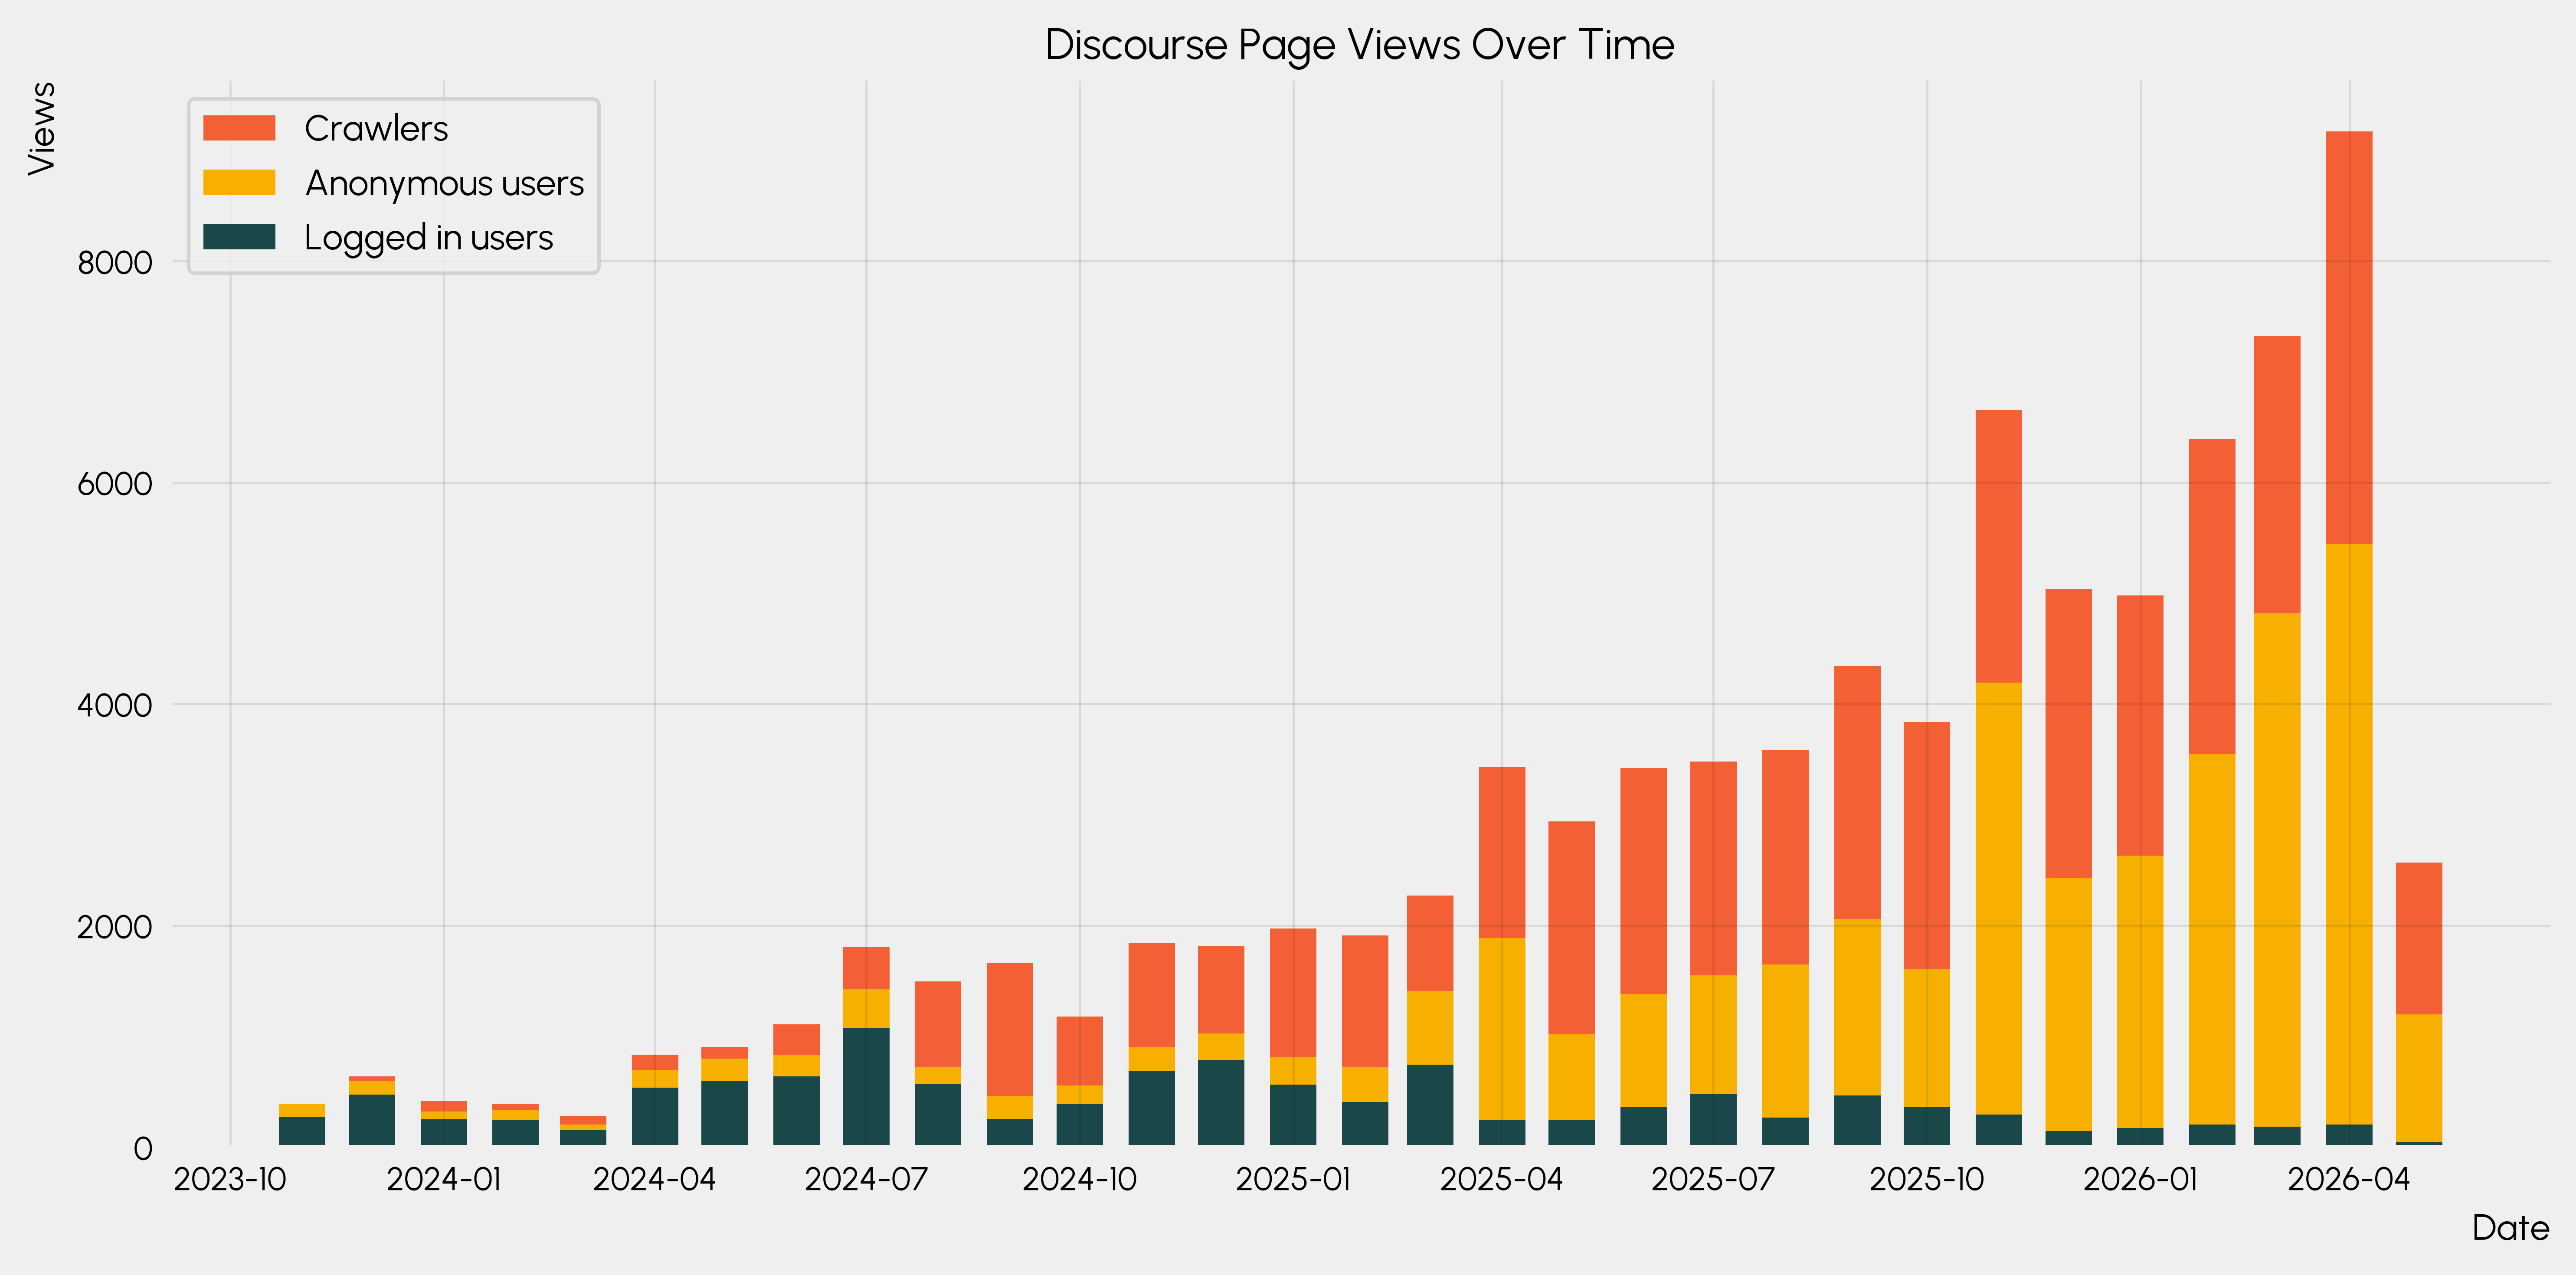

In [9]:
import matplotlib.pyplot as plt


def plot_page_views(width=20):
    x = (
        discourse_page_views_monthly.index.to_timestamp()
        if hasattr(discourse_page_views_monthly.index, "to_timestamp")
        else discourse_page_views_monthly.index
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Logged in users"],
        label="Logged in users",
        width=width,
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Anonymous users"],
        bottom=discourse_page_views_monthly["Logged in users"],
        label="Anonymous users",
        width=width,
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Crawlers"],
        bottom=discourse_page_views_monthly["Logged in users"]
        + discourse_page_views_monthly["Anonymous users"],
        label="Crawlers",
        width=width,
    )


plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_page_views(width=20)
plt.title("Discourse Page Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend(reverse=True)
plt.tight_layout()
plt.show()

## Discourse signups

In [10]:
url = "https://festim.discourse.group/admin/reports/signups.json"
url += f"?chart_grouping=monthly&end_date={end_date}&start_date={start_date}"

payload = {}
headers = {"Accept": "application/json", "Api-Key": API_KEY, "Api-Username": "remidm"}

response = requests.request("GET", url, headers=headers, data=payload)
response
response_data = json.loads(response.text)
response_data


{'report': {'type': 'signups',
  'title': 'Signups',
  'xaxis': 'Day',
  'yaxis': 'Number of signups',
  'description': 'New account registrations for this period.',
  'description_link': None,
  'data': [{'x': '2023-11-23', 'y': 1},
   {'x': '2023-11-27', 'y': 3},
   {'x': '2023-12-04', 'y': 1},
   {'x': '2023-12-05', 'y': 1},
   {'x': '2023-12-13', 'y': 1},
   {'x': '2024-01-25', 'y': 1},
   {'x': '2024-04-06', 'y': 1},
   {'x': '2024-04-19', 'y': 1},
   {'x': '2024-04-26', 'y': 1},
   {'x': '2024-05-07', 'y': 1},
   {'x': '2024-05-16', 'y': 1},
   {'x': '2024-05-25', 'y': 1},
   {'x': '2024-06-27', 'y': 1},
   {'x': '2024-07-12', 'y': 1},
   {'x': '2024-07-22', 'y': 1},
   {'x': '2024-07-23', 'y': 1},
   {'x': '2024-07-24', 'y': 1},
   {'x': '2024-07-25', 'y': 1},
   {'x': '2024-08-01', 'y': 1},
   {'x': '2024-08-30', 'y': 1},
   {'x': '2024-09-23', 'y': 1},
   {'x': '2024-10-06', 'y': 1},
   {'x': '2024-10-07', 'y': 1},
   {'x': '2024-10-18', 'y': 1},
   {'x': '2024-11-01', 'y': 1}

In [11]:
report_data = response_data["report"]["data"]
signups_data_x = [datetime.strptime(point['x'], "%Y-%m-%d") for point in report_data]
signups_data_y = [point['y'] for point in report_data]

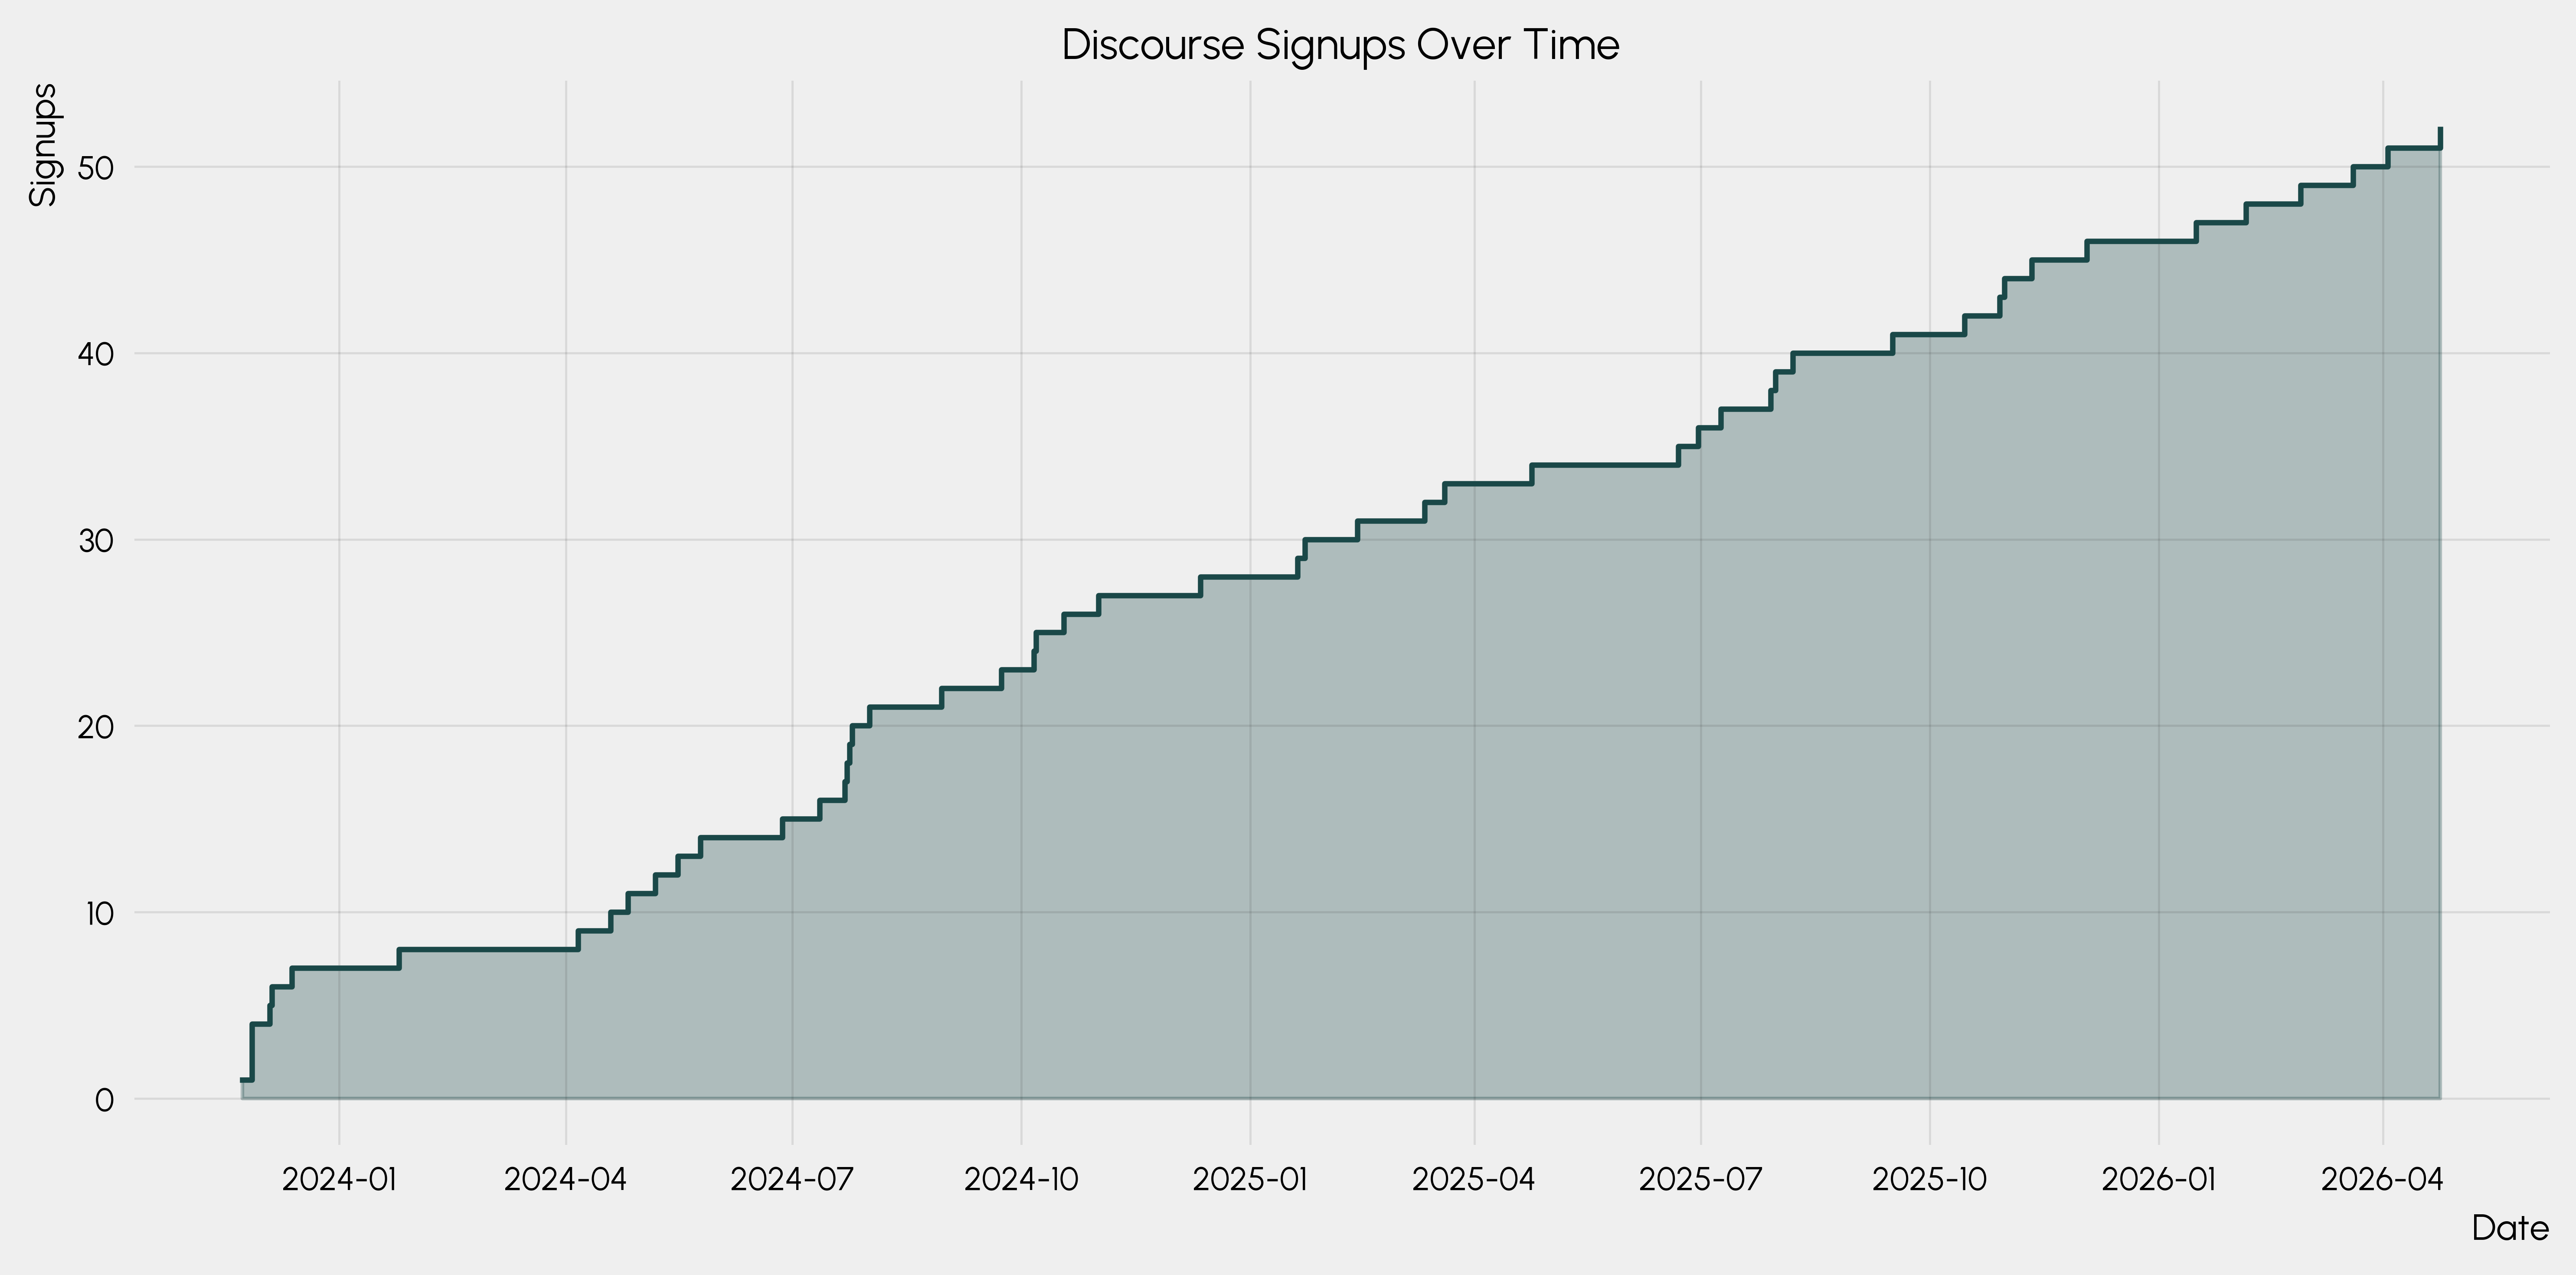

In [12]:
import numpy as np

def plot_signups(fill_between=True, **kwargs):
    cumulative_signups = np.cumsum(signups_data_y)
    (l,) = plt.step(signups_data_x, cumulative_signups, where="post", **kwargs)
    if fill_between:
        plt.fill_between(signups_data_x, cumulative_signups, alpha=0.3, color=l.get_color(), step="post")

    return signups_data_x, cumulative_signups


plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_signups()
plt.title("Discourse Signups Over Time")
plt.xlabel("Date")
plt.ylabel("Signups")
plt.tight_layout()
plt.show()

## Star history

In [13]:
import requests

OWNER = "festim-dev"
REPO = "festim"


url = f"https://api.github.com/repos/{OWNER}/{REPO}/stargazers"
headers = {
    "Accept": "application/vnd.github.v3.star+json",
    # "Authorization": f"Bearer {TOKEN}",  # uncomment for higher rate limits
}
page = 1
all_stars = []
while True:
    url = f"https://api.github.com/repos/{OWNER}/{REPO}/stargazers"
    # NOTE there seems to be a limit of 100 per page, so we need to paginate through the results
    response = requests.get(
        url, headers=headers, params={"per_page": 100, "page": page}
    )
    data = response.json()

    if not data:
        break

    all_stars.extend(data)
    page += 1

In [14]:
# Each item now has "starred_at" and "user"
for star in all_stars:
    print(star["starred_at"], star["user"]["login"])

2021-12-13T20:33:01Z mougenj
2022-07-27T12:22:30Z stephen-dixon
2022-07-27T12:34:14Z shimwell
2022-07-27T12:42:03Z jhillairet
2022-07-27T13:30:40Z BilelJegham
2022-07-27T13:44:39Z tianyikillua
2022-07-27T18:36:04Z giovanni-mariano
2022-08-08T22:30:23Z tkoyama010
2022-08-12T11:52:39Z StephDlpmtn
2022-08-12T23:59:54Z pshriwise
2022-08-19T06:58:50Z tengfeideng
2022-08-29T13:12:55Z ehodille
2022-09-13T15:36:45Z MKastek
2022-09-29T07:30:47Z liliangillier
2022-10-23T08:21:00Z husni-zuhdi
2022-12-13T22:51:24Z jlogan-cfs
2022-12-14T16:29:29Z lcarasik
2023-01-10T00:15:43Z george-poole
2023-06-21T06:59:44Z XuesenYang
2023-07-09T12:14:02Z FranFani
2023-07-09T12:31:20Z DinushaJ
2023-07-09T14:12:28Z FuerstT
2023-07-09T15:41:32Z PXC998
2023-07-09T15:41:38Z jehbice
2023-07-09T15:41:46Z niamh-holland
2023-07-09T15:41:47Z steven-van-boxel
2023-07-09T15:41:49Z zhengs-cn
2023-07-09T15:41:51Z AMPechero
2023-07-09T15:41:57Z odvorak89
2023-07-09T15:42:15Z LukeFisherUKAEA
2023-07-09T15:42:18Z AKI-1997
2023-0

In [15]:
from numpy import cumsum
from datetime import datetime

# Convert "starred_at" to datetime and sort
star_dates = sorted(
    [datetime.strptime(star["starred_at"], "%Y-%m-%dT%H:%M:%SZ") for star in all_stars]
)
# Create a cumulative count of stars over time
cumulative_stars = cumsum([1] * len(star_dates))

Text(0, 1, 'Cumulative Stars')

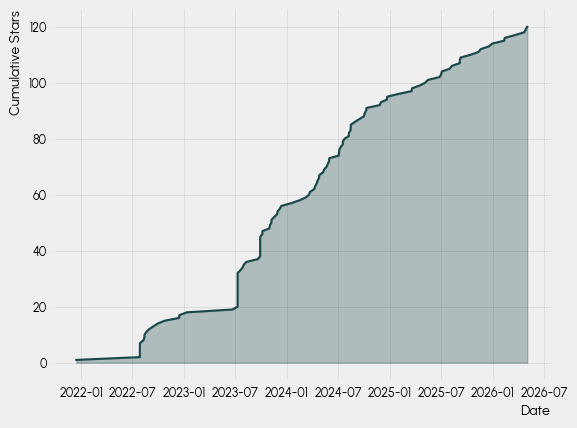

In [16]:
import matplotlib.pyplot as plt


def plot_star_history(fillbetween=True):
    (l,) = plt.plot(star_dates, cumulative_stars)
    if fillbetween:
        plt.fill_between(star_dates, cumulative_stars, alpha=0.3, color=l.get_color())

    return l


plot_star_history()
plt.xlabel("Date")
plt.ylabel("Cumulative Stars")

## User workshops

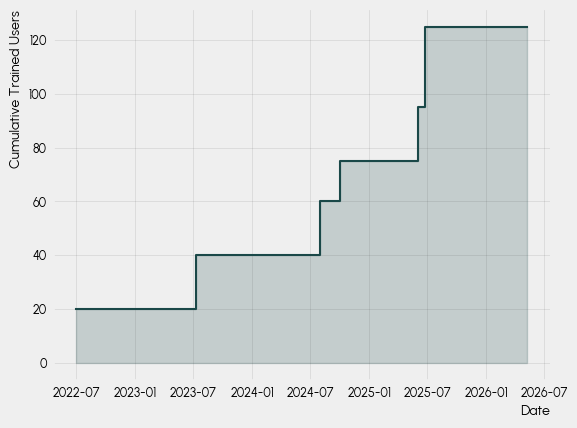

In [17]:
import numpy as np

workshop_data = [
    {
        "name": "SOFE 2025",
        "date": datetime(2025, 6, 23),
        "attendees": 30,
    },
    {
        "name": "SOFE 2023",
        "date": datetime(2023, 7, 9),
        "attendees": 20,
    },
    {
        "name": "CEA LMJ",
        "date": datetime(2025, 6, 1),
        "attendees": 20,
    },
    {
        "name": "UKAEA",
        "date": datetime(2024, 8, 1),
        "attendees": 20,
    },
    {
        "name": "IPP Garching",
        "date": datetime(2024, 9, 30),
        "attendees": 15,
    },
    {
        "name": "Kyoto Fusioneering",
        "date": datetime(2022, 7, 1),
        "attendees": 20,
    },
]


def plot_trained_users_over_time(workshop_data, fill_between=True):
    _workshop_data = sorted(workshop_data, key=lambda x: x["date"])

    cumulative_trained_users = np.cumsum(
        [workshop["attendees"] for workshop in _workshop_data]
    )
    workshop_dates = [workshop["date"] for workshop in _workshop_data]

    # add today with the latest number
    workshop_dates.append(datetime.today())
    cumulative_trained_users = np.append(
        cumulative_trained_users, cumulative_trained_users[-1]
    )

    (l,) = plt.step(workshop_dates, cumulative_trained_users, where="post")
    if fill_between:
        plt.fill_between(
            workshop_dates,
            cumulative_trained_users,
            step="post",
            alpha=0.2,
            color=l.get_color(),
        )

    return workshop_dates, cumulative_trained_users


plt.figure()
plot_trained_users_over_time(workshop_data)
plt.xlabel("Date")
plt.ylabel("Cumulative Trained Users")
plt.show()


## Main figure

In [18]:
def extrapolate_data(xs, ys, future_date):
    # Fit a linear model to the existing data
    x = np.array([(date - xs[0]).days for date in xs])
    y = ys
    coeffs = np.polyfit(x, y, 1)  # Linear fit
    slope, intercept = coeffs

    # Extrapolate to the future date
    future_x = (future_date - xs[0]).days
    extrapolated_y = slope * future_x + intercept

    return extrapolated_y

In [19]:
def add_milestone(
    date, label, text_kwargs=None, line_kwargs=None, xytext=(0, 10), arrow=False
):
    if text_kwargs is None:
        text_kwargs = {}
    if line_kwargs is None:
        line_kwargs = {}
    l = plt.axvline(x=date, **line_kwargs)
    # text above the line
    if arrow:
        arrowprops = dict(arrowstyle="-", color=l.get_color(), linestyle="dashed")
    else:
        arrowprops = None
    plt.annotate(
        label,
        xy=(date, 1),
        xytext=xytext,
        textcoords="offset points",
        ha="center",
        color=l.get_color(),
        arrowprops=arrowprops,
        **text_kwargs,
    )
    return l


def add_period(start, end, label, text_kwargs=None, line_kwargs=None):
    if text_kwargs is None:
        text_kwargs = {}
    if line_kwargs is None:
        line_kwargs = {}
    plt.axvspan(start, end, alpha=0.3, **line_kwargs)
    plt.annotate(
        label,
        xy=((start + (end - start) / 2), 0.5),
        va="center",
        ha="center",
        **text_kwargs,
    )

def add_datapoint_annotation(x, y, text=True, xytext=(0, 10), **kwargs):
    plt.scatter(x, y, **kwargs)
    if text:
        plt.annotate(
            f"{y}",
            xy=(x, y),
            xytext=xytext,
            textcoords="offset points",
            ha="center",
            fontsize=12,
            alpha=kwargs.get("alpha", 1.0),
            color=kwargs.get("color", "C0")
        )


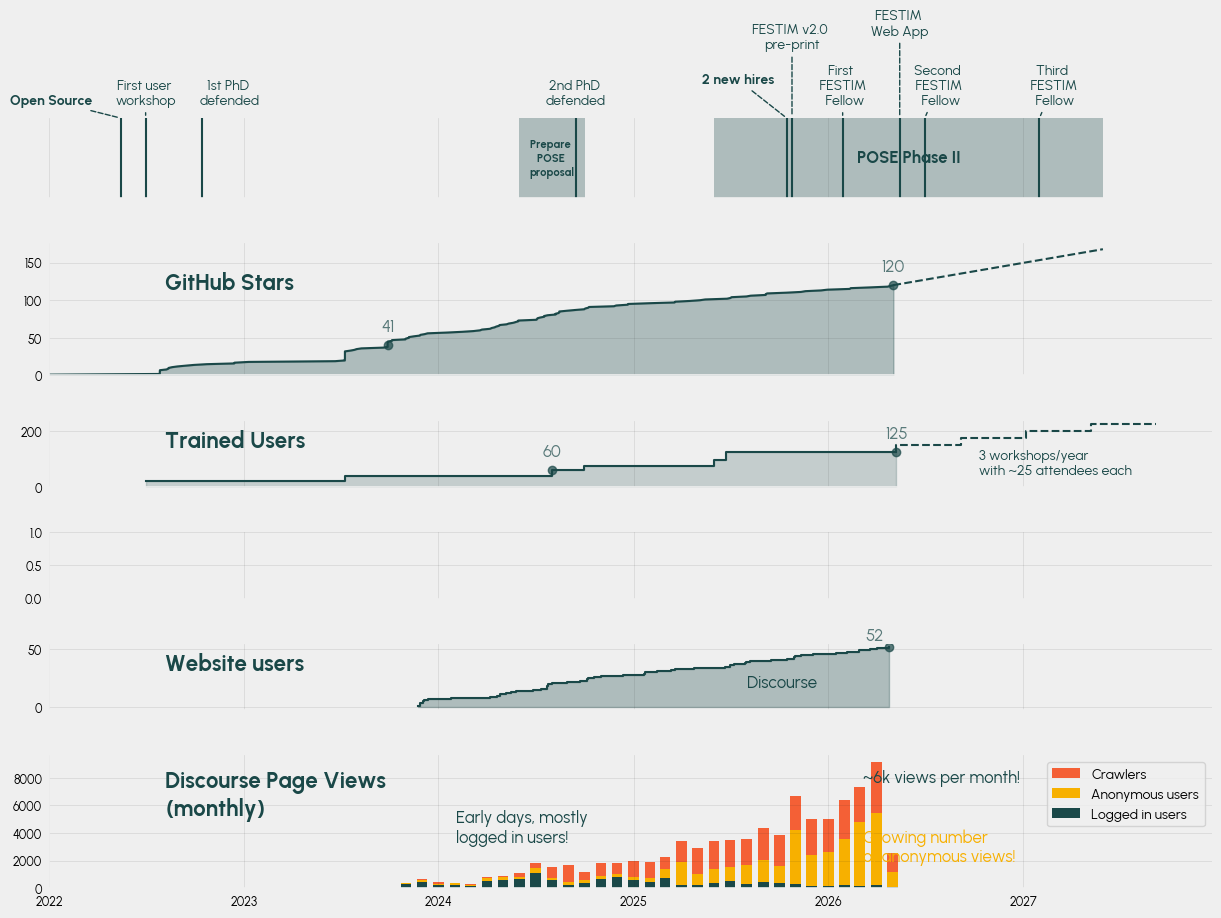

In [20]:
phase_ii_start = datetime(2025, 6, 1)
phase_ii_end = datetime(2027, 5, 31)

title_coords = (0.1, 0.7)
title_colour = "C0"

fig, axs = plt.subplots(
    nrows=6,
    ncols=1,
    sharex=True,
    figsize=(15, 10),
    height_ratios=[0.6, 1, 0.5, 0.5, 0.5, 1],
)

plt.subplots_adjust(hspace=0.5)


plt.sca(axs[1])
l = plot_star_history()
extrapolate_stars_nb = extrapolate_data(star_dates, cumulative_stars, phase_ii_end)
plt.plot(
    [star_dates[-1], phase_ii_end],
    [cumulative_stars[-1], extrapolate_stars_nb],
    linestyle="--",
    color=l.get_color(),
)
add_datapoint_annotation(
    star_dates[-80], cumulative_stars[-80], color=l.get_color(), alpha=0.7
)
add_datapoint_annotation(
    star_dates[-1], cumulative_stars[-1], color=l.get_color(), alpha=0.7
)

plt.annotate(
    "GitHub Stars",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.ylim(bottom=0)


plt.sca(axs[2])
workshop_dates, cumulative_trained_users = plot_trained_users_over_time(workshop_data)

# 3 workshops a year with ~25 ppls each
nb_workshops_per_year = 3
ppl_per_workshop = 25
new_workshop_dates = [
    workshop_dates[-1] + pd.Timedelta(days=365 * i / nb_workshops_per_year)
    for i in range(1, 5)
]
new_cumulative_trained_users = (
    cumulative_trained_users[-1] + np.arange(1, 5) * ppl_per_workshop
)

# add last point
new_workshop_dates.insert(0, workshop_dates[-1])
new_cumulative_trained_users = np.insert(
    new_cumulative_trained_users, 0, cumulative_trained_users[-1]
)
plt.step(
    new_workshop_dates,
    new_cumulative_trained_users,
    linestyle="--",
    color=l.get_color(),
)

for index in [-1, -5]:  # annotate the last and the 5th last point
    add_datapoint_annotation(
        workshop_dates[index],
        cumulative_trained_users[index],
        color=l.get_color(),
        alpha=0.7,
    )

plt.annotate(
    "Trained Users",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.annotate(
    "3 workshops/year \nwith ~25 attendees each",
    xy=(0.8, 0.2),
    xycoords="axes fraction",
    ha="left",
    fontsize=10,
    color="C0",
)

plt.ylim(bottom=0)

plt.sca(axs[3])


plt.ylim(bottom=0)

plt.sca(axs[4])
dates_signups, signups_cumul = plot_signups(label="Discourse signups")

plt.annotate(
    "Website users",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)
plt.annotate(
    f"Discourse",
    xy=(0.6, 0.35),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C0",
)


for dates, cumul, color, xytext in [
    (dates_signups, signups_cumul, "C0", (-10, 5)),
]:
    index = -1  # annotate the last point
    add_datapoint_annotation(
            dates[index],
            cumul[index],
            color=color,
            alpha=0.7,
            xytext=xytext,
        )


# plt.legend(reverse=True)
# plt.ylim(bottom=0, top=400)

plt.sca(axs[5])
plot_page_views(width=20)
plt.annotate(
    "Discourse Page Views\n(monthly)",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.annotate(
    "Early days, mostly\nlogged in users!",
    xy=(0.35, 0.35),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C0",
)
plt.annotate(
    "Growing number \nof anonymous views!",
    xy=(0.7, 0.2),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C1",
)
plt.annotate(
    "~6k views per month!",
    xy=(0.7, 0.8),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C0",
)
plt.legend(reverse=True)
plt.ylim(bottom=0)

plt.sca(axs[0])

add_milestone(
    datetime(2022, 5, 15),
    "Open Source",
    xytext=(-50, 10),
    arrow=True,
    text_kwargs={"font": bold_font},
)
add_milestone(datetime(2022, 10, 15), "1st PhD \ndefended", xytext=(20, 10))
add_milestone(datetime(2024, 9, 15), "2nd PhD \ndefended", xytext=(0, 10))
add_milestone(workshop_dates[0], "First user \nworkshop", xytext=(0, 10), arrow=True)
# add_milestone(ga_users_dates[0], "Google \nAnalytics", xytext=(-25, -25), arrow=True)
add_milestone(datetime(2026, 5, 15), "FESTIM \nWeb App", xytext=(0, 60), arrow=True)
add_milestone(datetime(2026, 1, 28), "First \n FESTIM \n Fellow", arrow=True)
add_milestone(
    datetime(2026, 7, 1), "Second \n FESTIM \n Fellow", xytext=(10, 10), arrow=True
)
add_milestone(
    datetime(2027, 2, 1), "Third \n FESTIM \n Fellow", xytext=(10, 10), arrow=True
)


add_period(
    datetime(2024, 6, 1),
    datetime(2024, 10, 1),
    label="Prepare \nPOSE \nproposal",
    text_kwargs={"color": "C0", "font": bold_font, "fontsize": 8},
)

add_period(
    phase_ii_start,
    phase_ii_end,
    label="POSE Phase II",
    text_kwargs={"color": "C0", "font": bold_font, "fontsize": 12},
)

add_milestone(
    datetime(2025, 10, 25), "FESTIM v2.0 \npre-print", xytext=(0, 50), arrow=True
)
add_milestone(
    datetime(2025, 10, 15),
    "2 new hires",
    xytext=(-35, +25),
    arrow=True,
    text_kwargs={"font": bold_font},
)

plt.gca().tick_params(axis='x', which='major', labelsize=20)

plt.gca().get_yaxis().set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.xlim(left=datetime(2022, 1, 1))
plt.savefig("timeline.svg")
plt.show()

## Citations

In [21]:
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import morethemes as mt
import numpy as np
from datetime import datetime

EMAIL = "darkj385@mit.edu"
BASE_URL = "https://api.openalex.org"

DOIS = [
    "10.1016/j.nme.2019.100709",
    "10.1016/j.ijhydene.2024.03.184",
    "10.1038/s41598-020-74844-w",
    "10.1088/1741-4326/abd95f",
    "10.1088/1741-4326/ac28b0",
    "10.1088/1741-4326/ad56a0",
    "10.1016/j.nme.2021.100984",
]

JOURNAL_ABBR = {
    "Nuclear Materials and Energy": "NME",
    "International Journal of Hydrogen Energy": "Int. J. Hydrog. Energy",
    "Nuclear Fusion": "Nucl. Fusion",
    "Scientific Reports": "Sci. Rep.",
}


def get_work(doi):
    return requests.get(f"{BASE_URL}/works/https://doi.org/{doi}?mailto={EMAIL}").json()


def get_citing_dates(doi):
    work = get_work(doi)
    bare_id = work["id"].split("/")[-1]
    citing, cursor = [], "*"
    while cursor:
        data = requests.get(
            f"{BASE_URL}/works?filter=cites:{bare_id}&select=publication_date&cursor={cursor}&mailto={EMAIL}"
        ).json()
        citing.extend(data["results"])
        cursor = data["meta"]["next_cursor"]
    surname = work["authorships"][0]["author"]["display_name"].split()[-1]
    journal = JOURNAL_ABBR.get(
        work["primary_location"]["source"]["display_name"],
        work["primary_location"]["source"]["display_name"],
    )
    pub_date = datetime.strptime(work["publication_date"], "%Y-%m-%d")
    label = f"{surname}, {journal}, {pub_date.year}"
    dates = sorted(datetime.strptime(p["publication_date"], "%Y-%m-%d") for p in citing)
    return dates, label, pub_date


def plot_cumulative_citations(dois):
    mt.set_theme("urban")
    plt.rcParams["axes.prop_cycle"] = plt.cycler(
        color=["#f46036", "#1a4848", "#f7b000", "#aceca1", "#c9f2c7"]
    )

    all_series = sorted([get_citing_dates(doi) for doi in dois], key=lambda x: x[2])
    all_dates = sorted({d for dates, _, __ in all_series for d in dates})

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    bottom = np.zeros(len(all_dates))

    for i, (dates, label, _) in enumerate(all_series):
        counts = np.array([sum(1 for d in dates if d <= t) for t in all_dates])
        top = bottom + counts
        c = colors[i % len(colors)]

        ax.fill_between(
            all_dates,
            bottom,
            top,
            step="post",
            alpha=0.7,
            color=c,
            label=label,
            edgecolor="none",
        )
        bottom = top
    ax.step(all_dates, top, where="post", linewidth=2, color="C1")

    ax.scatter(all_dates[-1], top[-1], color="C1", edgecolor="black", zorder=5, s=40)

    ax.annotate(
        f"{top[-1]:.0f} citations",
        xy=(all_dates[-1], top[-1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
    )

    ax.set(
        xlabel="Date",
        ylabel="Cumulative citations",
        title="Cumulative citations over time",
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=7, reverse=True)
    plt.tight_layout()
    plt.savefig("cumulative_citations.png", dpi=150, bbox_inches="tight")
    plt.show()


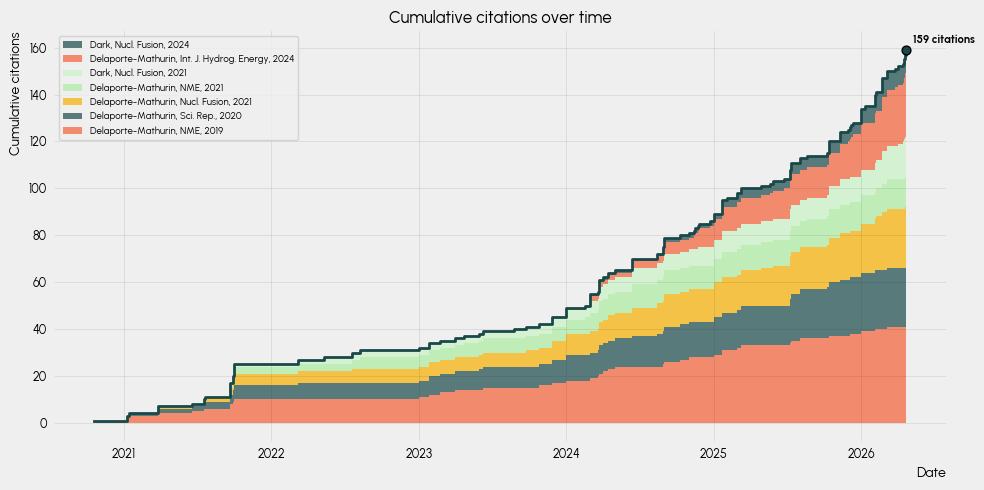

In [ ]:
plot_cumulative_citations(DOIS)